In [4]:
import os
import sys
import seaborn as sns

from Opt_Frame import *
from Experiment import *

ROOT_ADDR = os.path.abspath(os.path.join(os.getcwd(), '..')) 

print(ROOT_ADDR)

sys.path.append(ROOT_ADDR)

from DAG_Model import *
from Static_Scheduler import *
from Dynamic_Scheduler import *



/home/fyj/Project/TG-RT-System


# 1. 数据输入

In [12]:
_in_path = "/home/fyj/Project/TG-RT-System/DAG_Model/Data/Idata/"
_out_path = "/home/fyj/Project/TG-RT-System/DAG_Model/Data/Odata/"

_dag_id = "Dag_0"
# "Dag_0", "Dag_1", "Dag_2", "Dag_3", "Self_DAG_1", "Self_DAG_2", "Self_DAG_3",
# "M1_S1_C1", "M1_S1_C2", "M1_S2_C1", "M1_S2_C2", "M2_S1_C1", "M2_S1_C2", "M2_S2_C1", "M2_S2_C2", "M2_S3_C1", "M2_S3_C2"

_arch_id = "Arch_Hete"
# "Arch_Hete_3",  "Arch_Hete", "Arch_Homo_3", "Arch_Homo"

_fn = f"{_dag_id}_{_arch_id}_Opt"

# (1) DAG Data (json addr);
_td = Dag_Json_Input(_in_path + f'/Task_New/{_dag_id}.json')

# (2) Processor Data (json addr);
_ta = Arch_Json_Input(_in_path + f'/System/{_arch_id}.json')

# (3) Max offset
_tm = sum([_wd for _ni in _td.nodes() for _arch, _feat in _td.nodes[_ni]['W'].items() for _fd, _wd in _feat.items()])

print(f"{_dag_id}\t{_arch_id}\tVol:{_tm}")

Dag_0	Arch_Hete	Vol:96


# 2. 遗传算法优化

In [ ]:
_in, _pn = 50, 128
_opt_rd, _opt_ind = Main(_td, _ta, _tm, _in, _pn)
_rd = copy.deepcopy(_td)

print(_opt_ind)
#  1. P
for _ni, _pi in enumerate(_opt_ind[0]):
    _rd.nodes[_ni]['P'] = _pi
#  2. O
for _ni, _oi in enumerate(_opt_ind[1]):
    _rd.nodes[_ni]['O'] = _oi
#  3. A
for _ni, _ai in enumerate(_opt_ind[2]):
    _rd.nodes[_ni]['A'] = _ai

Dag_Json_Output(_rd, _fn, _in_path + "/Task_Opt/")

pd.DataFrame(_opt_rd).to_csv(_out_path + "/Exam/" + _fn + ".csv", index=False)

	Generation 0:	99.00 -- 1.46 -- Current time:2025-07-25 17:49:39.654793 
	Generation 1:	85.00 -- 1.53 -- Current time:2025-07-25 17:49:41.184328 
	Generation 2:	82.00 -- 1.53 -- Current time:2025-07-25 17:49:42.714834 
	Generation 3:	72.00 -- 1.36 -- Current time:2025-07-25 17:49:44.072156 
	Generation 4:	70.00 -- 1.38 -- Current time:2025-07-25 17:49:45.449628 
	Generation 5:	61.00 -- 1.32 -- Current time:2025-07-25 17:49:46.767132 
	Generation 6:	61.00 -- 1.18 -- Current time:2025-07-25 17:49:47.947544 
	Generation 7:	55.00 -- 1.19 -- Current time:2025-07-25 17:49:49.142181 
	Generation 8:	51.00 -- 1.45 -- Current time:2025-07-25 17:49:50.589777 
	Generation 9:	48.00 -- 1.21 -- Current time:2025-07-25 17:49:51.799772 
	Generation 10:	46.00 -- 1.23 -- Current time:2025-07-25 17:49:53.029758 
	Generation 11:	46.00 -- 1.24 -- Current time:2025-07-25 17:49:54.267297 
	Generation 12:	44.00 -- 1.16 -- Current time:2025-07-25 17:49:55.424803 
	Generation 13:	44.00 -- 1.12 -- Current time:20

# 3. 实验结果展示

Ori:
	Max:32.00
	Min:32.00
	Std:0.00
	Avg:32.00
Opt:
	Max:22.00
	Min:22.00
	Std:0.00
	Avg:22.00


<Axes: >

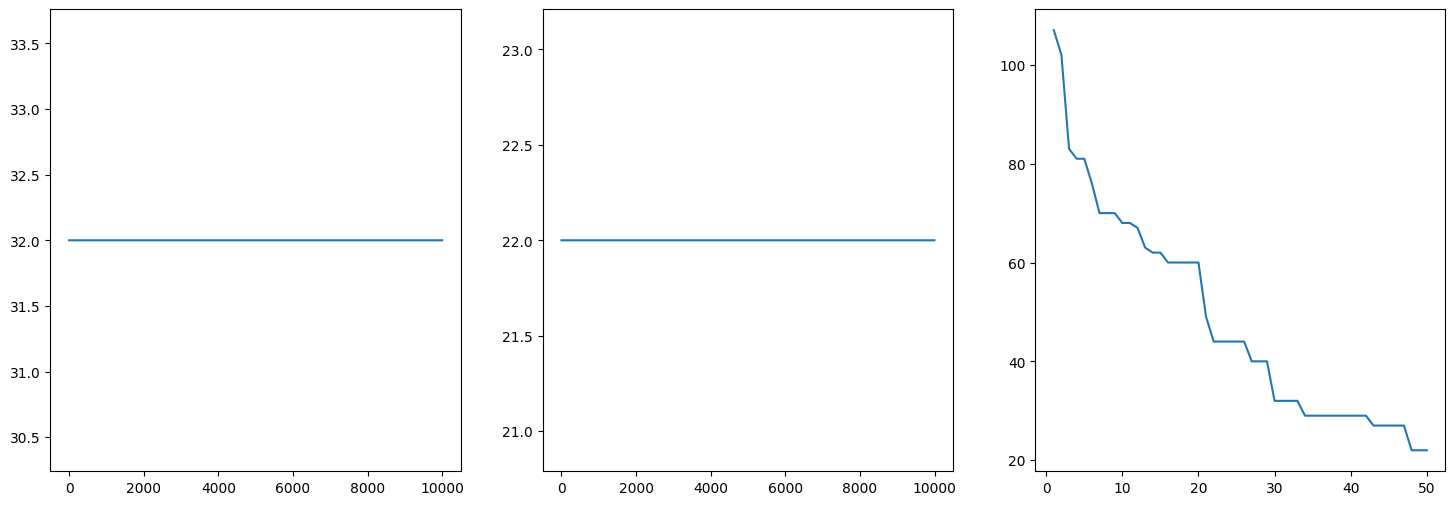

In [13]:
_exam_num = 10000
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
_od = Dag_Json_Input(_in_path + f'/Task_Opt/{_fn}.json')
_idf = pd.read_csv(_out_path + "/Exam/" + _fn + ".csv")  # 本地文件路径或URL  

# (1) 原始配置
_ms_ori = list()
for _ in range(_exam_num):
    _WS = WorkStation(copy.deepcopy(_td), copy.deepcopy(_ta))
    _r = _WS.run()
    _ms_ori.append(max([_rx['ft'] for _rx in _r]))

print(f"Ori:")
print(f"\tMax:{max(_ms_ori):.2f}")
print(f"\tMin:{min(_ms_ori):.2f}")
print(f"\tStd:{np.std(_ms_ori):.2f}")
print(f"\tAvg:{np.mean(_ms_ori):.2f}")

# (2) 优化配置
_ms_opt = list()
for _ in range(_exam_num):
    _WS = WorkStation(_od, _ta)
    _r = _WS.run()
    _ms_opt.append(max([_rx['ft'] for _rx in _r]))

print(f"Opt:")
print(f"\tMax:{max(_ms_opt):.2f}")
print(f"\tMin:{min(_ms_opt):.2f}")
print(f"\tStd:{np.std(_ms_opt):.2f}")
print(f"\tAvg:{np.mean(_ms_opt):.2f}")

# axs[0].set_ylim(500000, 4000000)
sns.lineplot(y=_ms_ori, x=range(_exam_num), ax=axs[0])

# axs[1].set_ylim(500000, 4000000)
sns.lineplot(y=_ms_opt, x=range(_exam_num), ax=axs[1])

# (3) 迭代图
# _sdf = _idf.sort_values(by='opt_fit')
# _ddd = list(_idf['min_1'])
# # _ddd.reverse()
# # print(_ddd)
_sdd = list(_idf['opt_fit'])

sns.lineplot( x = list(range(1, len(_sdd) + 1)), y = _sdd )
